WITHIN-PARTICIPANT RSA, two different versions

hypothesis: Hippocampus patterns for moral events are shaped by a common latent structure (e.g., moral schema). Non-moral events are more heterogeneous — each event may have different patterns because there’s no shared “category-level” representation underlying it, over and above the shared narrative that all sentences have in common. That means that two moral events, moral-event1 and moral-event2, will have a similar spatial pattern pearson correlation score as moral-event1 to moral-event3, because despite moral-event2 and moral-event3 being different events, they have the same underlying moral schema. 

version1: odd-even event split, with computing an average spatial pattern across the hippocampal voxels of the various TRs within a given event/sentence. Testing category-level representational geometry, with the logic of treating all sentences that are moral as instances of the same category (sort of similar logic as perception RSA studies do with picture of birdA, birdB etc in visual cortex region, somewhat different though because they will show the same pictures multiple times, counterbalanced across runs to avoid temporal autocorrelation). 

version2: within-event split: if morality influences event representation in the hippocampus in the same way all the time, it will lead to more stable event-representations within-event compared to non-moral sentences.

In [1]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns


In [2]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

whichFoundationScore = "MAC_a_moral_nonmoral"

In [3]:
# ------------------------
# Load 
# ------------------------

whichROI = "hippocampus" 

whichStory = "21styear"  # tunnel, 21styear, shapessocial, prettymouthaffair,prettymouthparanoia

base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

# make sure foundation scores for pretty mouth are found
if whichStory == 'prettymouthaffair':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichStory == 'prettymouthparanoia':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
else:
    print('use foundation scores of WhichStory')
    foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"

left = np.load(data_dir + f"{whichStory}_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_{whichROI}_R_3D_clean.npy")



use foundation scores of WhichStory
21styear
hippocampus


In [4]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec

foundationScoresSelect = foundationScores[[whichFoundationScore,"start","end"]]
foundationScoresSelect = foundationScoresSelect.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect["startTR"] = foundationScoresSelect["start"] / 1.5
foundationScoresSelect["endTR"] = foundationScoresSelect["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect["startTR"] = foundationScoresSelect["startTR"].round(0).astype(int)
foundationScoresSelect["endTR"] = foundationScoresSelect["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect['startTR'] = foundationScoresSelect['startTR'] + 3
foundationScoresSelect['endTR'] = foundationScoresSelect['endTR'] + 3


In [5]:
# split into the moral vs non moral sentences
foundationScoresSelect_nonzero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] != 0]

foundationScoresSelect_zero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] == 0]


## split in odd vs even events (so, separate events and compute mean pattern across TRs within an event to use)

Running RSA for moral sentences...
Running RSA for non-moral sentences...
Paired t-test: t(24) = 15.292, p = 0.0000
Mean RSA moral: 0.40437723441048073 Mean RSA non-moral: 0.24105356957267754


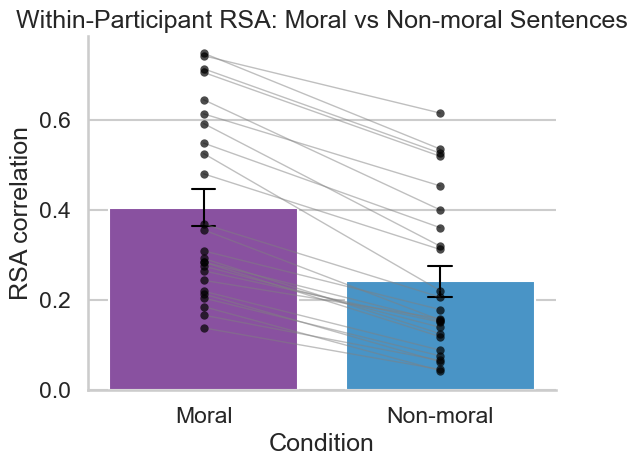

In [6]:
# ================================================================
def run_within_participant_rsa(data_array, events):
    """
    data_array : np.ndarray, shape (voxels x volumes x participants)
    events     : DataFrame with columns ['startTR', 'endTR']
    Returns    : np.array of RSA correlations per participant
    """
    # Sort and clean events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    event_ids = events.index.values

    # Odd/even split to minimize temporal autocorrelation
    split1_ids = event_ids[::2]
    split2_ids = event_ids[1::2]

    # Equalize length
    n_events = min(len(split1_ids), len(split2_ids))
    split1_ids = split1_ids[:n_events]
    split2_ids = split2_ids[:n_events]

    n_participants = data_array.shape[2]
    results = []

    for p in range(n_participants):
        data = data_array[:, :, p].copy()
        data = zscore(data, axis=1, ddof=1)  # normalize voxelwise over time

        split1_patterns, split2_patterns = [], []

        for eid in split1_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split1_patterns.append(pattern)

        for eid in split2_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split2_patterns.append(pattern)

        split1_patterns = np.column_stack(split1_patterns)
        split2_patterns = np.column_stack(split2_patterns)

        # Compute representational dissimilarity matrices (1 - Pearson correlation)
        rdm1 = squareform(pdist(split1_patterns.T, metric='correlation'))
        rdm2 = squareform(pdist(split2_patterns.T, metric='correlation'))

        # Vectorize upper triangles and correlate (Spearman)
        iu = np.triu_indices(n_events, k=1)
        rsa_corr, _ = spearmanr(rdm1[iu], rdm2[iu])
        results.append(rsa_corr)

    return np.array(results)


# ================================================================
# Run RSA separately for moral and non-moral events
# ================================================================
print("Running RSA for moral sentences...")
rsa_moral_left  = run_within_participant_rsa(left,  foundationScoresSelect_nonzero)
rsa_moral_right = run_within_participant_rsa(right, foundationScoresSelect_nonzero)

print("Running RSA for non-moral sentences...")
rsa_nonmoral_left  = run_within_participant_rsa(left,  foundationScoresSelect_zero)
rsa_nonmoral_right = run_within_participant_rsa(right, foundationScoresSelect_zero)

# ================================================================
# Average across hemispheres and compute difference
# ================================================================
rsa_moral_mean    = (rsa_moral_left + rsa_moral_right) / 2
rsa_nonmoral_mean = (rsa_nonmoral_left + rsa_nonmoral_right) / 2
rsa_diff          = rsa_moral_mean - rsa_nonmoral_mean

# ================================================================
# Combine into one DataFrame
# ================================================================
rsa_df = pd.DataFrame({
    'participant': np.arange(len(rsa_moral_mean)),
    'rsa_moral_left': rsa_moral_left,
    'rsa_moral_right': rsa_moral_right,
    'rsa_moral_mean': rsa_moral_mean,
    'rsa_nonmoral_left': rsa_nonmoral_left,
    'rsa_nonmoral_right': rsa_nonmoral_right,
    'rsa_nonmoral_mean': rsa_nonmoral_mean,
    'rsa_diff': rsa_diff
})

# ================================================================
# === Group stats: paired t-test ===
# ================================================================
diffs = rsa_df['rsa_moral_mean'] - rsa_df['rsa_nonmoral_mean']
t_stat, p_val = ttest_rel(rsa_df['rsa_moral_mean'], rsa_df['rsa_nonmoral_mean'])

print("Paired t-test: t({}) = {:.3f}, p = {:.4f}".format(len(diffs)-1, t_stat, p_val))
print("Mean RSA moral:", rsa_df['rsa_moral_mean'].mean(), 
      "Mean RSA non-moral:", rsa_df['rsa_nonmoral_mean'].mean())

plt.figure(figsize=(6, 5))
sns.set(style='whitegrid', context='talk')

# ================================================================
# Prepare for plotting
# ================================================================
plot_df = pd.melt(
    rsa_df,
    id_vars=['participant'],
    value_vars=['rsa_moral_mean', 'rsa_nonmoral_mean'],
    var_name='Condition',
    value_name='RSA'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'rsa_moral_mean': 'Moral',
    'rsa_nonmoral_mean': 'Non-moral'
})

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='RSA', hue='Condition', legend=False,
    errorbar='se', capsize=0.1,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB']
)

# Overlay participant dots + connecting lines
sns.stripplot(
    data=plot_df,
    x='Condition', y='RSA',
    color='black', size=6, jitter=False, alpha=0.7
)

# Connect participant dots
for pid in rsa_df['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'RSA'].values
    plt.plot([0, 1], vals, color='gray', alpha=0.5, linewidth=1)

ax.set_title('Within-Participant RSA: Moral vs Non-moral Sentences')
ax.set_ylabel('RSA correlation')
sns.despine()
plt.tight_layout()
plt.show()

## split within event to have odd event split within event instead of across event

Running within-event split RSA for moral sentences...
Running within-event split RSA for non-moral sentences...
Paired t-test: t(24) = 4.952, p = 0.0000
Mean RSA moral: 0.3292387325057986 Mean RSA non-moral: 0.3104566736639399


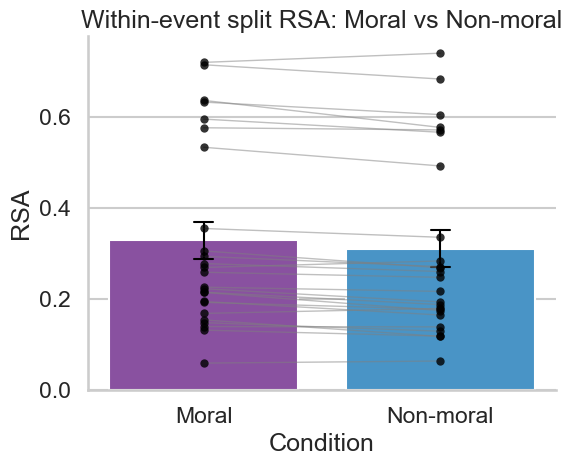

In [7]:

# === compute per-event split patterns (odd/even TRs within event) ===
def event_split_patterns_for_events(events):
    """
    Given events DataFrame with integer 'startTR' and 'endTR', produce
    for each event the indices of TRs for split A and split B (odd/even within event).
    Returns:
      valid_event_idx: list of event indices that have at least one TR in each split
      splitA_tr_indices: list of lists (TR indices for split A per valid event)
      splitB_tr_indices: list of lists (TR indices for split B per valid event)
    """
    valid_event_idx = []
    splitA_tr_indices = []
    splitB_tr_indices = []
    
    for i, ev in events.iterrows():
        s = int(ev['startTR'])
        e = int(ev['endTR'])
        # full list of TR indices for this event
        trs = np.arange(s, e + 1)
        if len(trs) == 0:
            continue
        # odd/even within the event (relative indexing)
        # choose trs with relative index %2 == 0 vs %2 == 1
        rel_idx = np.arange(len(trs))
        a_trs = trs[rel_idx % 2 == 0]
        b_trs = trs[rel_idx % 2 == 1]
        # require at least one TR in each split
        if len(a_trs) >= 1 and len(b_trs) >= 1:
            valid_event_idx.append(i)
            splitA_tr_indices.append(a_trs)
            splitB_tr_indices.append(b_trs)
    return valid_event_idx, splitA_tr_indices, splitB_tr_indices

# === RSA function using within-event split ===
def run_within_event_rsa(data_array, events):
    """
    data_array : np.ndarray with shape (voxels, n_volumes, n_participants)
    events     : DataFrame with 'startTR' and 'endTR' (integers)
    Returns    : np.array of RSA correlations per participant (hemisphere)
    """
    # Clean & ensure integer TRs
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR']   = events['endTR'].astype(int)
    
    # Build split TR lists per event, dropping events that don't have at least one TR in both splits
    valid_event_idx, splitA_trs_list, splitB_trs_list = event_split_patterns_for_events(events)
    n_events = len(valid_event_idx)
    if n_events < 2:
        raise ValueError("Not enough valid events after within-event splitting.")
    
    n_participants = data_array.shape[2]
    rsa_results = np.full(n_participants, np.nan)
    
    for p in range(n_participants):
        # voxel x time
        data = data_array[:, :, p].copy()
        # normalize voxel timecourses to be comparable (zscore across time per voxel)
        data = zscore(data, axis=1, ddof=1)
        
        # build per-event pattern estimates for split A and split B
        patternsA = []
        patternsB = []
        for a_trs, b_trs in zip(splitA_trs_list, splitB_trs_list):
            # mean over the specified TRs (axis=1 collapsed)
            patA = np.mean(data[:, a_trs], axis=1)
            patB = np.mean(data[:, b_trs], axis=1)
            patternsA.append(patA)
            patternsB.append(patB)
        
        # stack to voxels x events
        patternsA = np.column_stack(patternsA)  # voxels x n_events
        patternsB = np.column_stack(patternsB)
        
        # compute RDMs
        rdmA = squareform(pdist(patternsA.T, metric='correlation'))
        rdmB = squareform(pdist(patternsB.T, metric='correlation'))
        
        # vectorize upper triangle
        iu = np.triu_indices(n_events, k=1)
        vecA = rdmA[iu]
        vecB = rdmB[iu]
        
        # Spearman between RDMs: assesses rank-order consistency across pairwise relations
        rho, _ = spearmanr(vecA, vecB)
        rsa_results[p] = rho
    
    return rsa_results

# === Run for moral and non-moral, both hemispheres ===
print("Running within-event split RSA for moral sentences...")
rsa_moral_left  = run_within_event_rsa(left,  foundationScoresSelect_nonzero)
rsa_moral_right = run_within_event_rsa(right, foundationScoresSelect_nonzero)

print("Running within-event split RSA for non-moral sentences...")
rsa_nonmoral_left  = run_within_event_rsa(left,  foundationScoresSelect_zero)
rsa_nonmoral_right = run_within_event_rsa(right, foundationScoresSelect_zero)

# average hemispheres
rsa_moral_mean    = (rsa_moral_left + rsa_moral_right) / 2
rsa_nonmoral_mean = (rsa_nonmoral_left + rsa_nonmoral_right) / 2
rsa_diff = rsa_moral_mean - rsa_nonmoral_mean

# assemble dataframe
rsa_df = pd.DataFrame({
    'participant': np.arange(len(rsa_moral_mean)),
    'rsa_moral_left': rsa_moral_left,
    'rsa_moral_right': rsa_moral_right,
    'rsa_moral_mean': rsa_moral_mean,
    'rsa_nonmoral_left': rsa_nonmoral_left,
    'rsa_nonmoral_right': rsa_nonmoral_right,
    'rsa_nonmoral_mean': rsa_nonmoral_mean,
    'rsa_diff': rsa_diff
})

# === Group stats: paired t-test ===
diffs = rsa_df['rsa_moral_mean'] - rsa_df['rsa_nonmoral_mean']
t_stat, p_val = ttest_rel(rsa_df['rsa_moral_mean'], rsa_df['rsa_nonmoral_mean'])

print("Paired t-test: t({}) = {:.3f}, p = {:.4f}".format(len(diffs)-1, t_stat, p_val))
print("Mean RSA moral:", rsa_df['rsa_moral_mean'].mean(), 
      "Mean RSA non-moral:", rsa_df['rsa_nonmoral_mean'].mean())

# === Plot ===
plt.figure(figsize=(6,5))
sns.set(style='whitegrid', context='talk')

plot_df = pd.melt(
    rsa_df,
    id_vars=['participant'],
    value_vars=['rsa_moral_mean', 'rsa_nonmoral_mean'],
    var_name='Condition',
    value_name='RSA'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'rsa_moral_mean': 'Moral',
    'rsa_nonmoral_mean': 'Non-moral'
})

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='RSA', hue='Condition', legend=False,
    errorbar='se', capsize=0.08,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB']
)

sns.stripplot(
    data=plot_df,
    x='Condition', y='RSA',
    color='black', size=6, jitter=False, alpha=0.8
)

# connect participant dots
for pid in rsa_df['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'RSA'].values
    plt.plot([0,1], vals, color='gray', alpha=0.5, linewidth=1)

ax.set_title('Within-event split RSA: Moral vs Non-moral')
ax.set_ylabel('RSA')
sns.despine()
plt.tight_layout()
plt.show()
